## Week 2: Shewhart Charts for Variables
### Dr. Austin Brown
### School of Data Science & Analytics

In [4]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "DesyneMartinez"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Slides//Week-2-Shewhart-Charts-for-Variables")

[1] "Repository already cloned to Colab."


In [3]:
getwd()

[1] "/content"

### Table of Contents
1. [Introduction to Control Charts](#introduction-to-control-charts)
2. [The Shewhart $\bar{X}$ and R Control Charts](#the-shewhart-x-and-r-control-charts)
3. [Process Capability](#process-capability)

---

## Introduction to Control Charts

As introduced last week, a control chart is a graphical monitoring tool rooted in statistical theory. Recall that all control charts share three key elements:

| Element | Description |
|---|---|
| **Plotting Statistic** | A summary statistic derived from random samples of the monitored process |
| **Target Value** | The in-control value the process ideally adheres to |
| **Control Limits** | Thresholds analogous to critical values in hypothesis testing |

A well-designed control chart balances two competing goals:

1. **Sensitivity** — if the process has shifted away from target, the chart signals in as few samples as possible
2. **Specificity** — if the process is in-control, false alarms are infrequent

---

### A Brief History

The original control chart, and still the most well-known, is the **Shewhart $\bar{X}$-chart**, developed by **Walter Shewhart** during his work at Bell Labs in the 1920s. Shewhart was a friend and mentor to **W. Edwards Deming**, widely regarded as the godfather of modern quality management.

---

## The Shewhart $\bar{X}$ and R Control Charts

When monitoring a continuous variable, we care about two things:

- **Process location** — is the mean staying where it should be?
- **Process variability** — is the spread of the process staying stable?

This is why the $\bar{X}$ and R charts are almost always used together:

| Chart | Monitors | Plotting Statistic |
|---|---|---|
| $\bar{X}$-chart | Process mean | Sample mean $\bar{x}_t$ |
| R-chart | Process variability | Sample range $R_t$ |

---

### Case 1: Known $\mu_0$ and $\sigma_0$

Assume the monitored process follows a Normal distribution with known in-control mean $\mu_0$ and standard deviation $\sigma_0$. At each time point $t = 1, 2, \ldots$ we collect a random sample of size $n$ and compute:

$$\bar{x}_t = \frac{1}{n}\sum_{i=1}^{n}x_i$$

By the **Central Limit Theorem**, as long as $X$ has finite variance:

$$\bar{x} \stackrel{\cdot}{\sim} N\!\left(\mu_0,\, \frac{\sigma_0}{\sqrt{n}}\right)$$

This gives us the $\bar{X}$-chart control limits:

$$UCL = \mu_0 + L\frac{\sigma_0}{\sqrt{n}}, \qquad CL = \mu_0, \qquad LCL = \mu_0 - L\frac{\sigma_0}{\sqrt{n}}$$

---

### Choosing $L$: The Role of $\alpha$

$L$ is chosen the same way we choose critical values in a two-sided $Z$-test. In both instances, we specify an acceptable $\alpha$ level, where $\alpha$ is the probability of a **false alarm** at any given time point.

- **$\alpha$ too large** → narrow control limits → too many false alarms
- **$\alpha$ too small** → wide control limits → real shifts go undetected

In practice, control charts are generally operated at $\alpha = 0.0027$, which yields $L = 3.00$. This is the origin of the term **Six Sigma**. A process running at $\pm 3\sigma$ from its mean produces very few nonconforming units.

---

### Case 2: Unknown $\mu_0$ and $\sigma_0$ (The Typical Case)

In practice, the true in-control parameters are rarely known and must be **estimated from historical data**. This is the work of **Phase I**.

Phase I is part of the **Analyze** and **Improve** components of the DMAIC process.

In Phase I, we collect $m$ historical samples of size $n$ and estimate:

$$\hat{\mu}_0 = \bar{\bar{x}} = \frac{1}{m}\sum_{i=1}^{m}\bar{x}_i$$

$$\hat{\sigma}_0 \approx \frac{\bar{R}}{d_2}, \qquad \text{where } \bar{R} = \frac{1}{m}\sum_{i=1}^{m}R_i$$

The estimated control limits for the $\bar{X}$-chart become:

$$UCL = \bar{\bar{x}} + \frac{3}{d_2\sqrt{n}}\bar{R}, \qquad CL = \bar{\bar{x}}, \qquad LCL = \bar{\bar{x}} - \frac{3}{d_2\sqrt{n}}\bar{R}$$

And for the R-chart:

$$UCL = D_4\bar{R}, \qquad CL = \bar{R}, \qquad LCL = D_3\bar{R}$$

$d_2$, $D_3$, and $D_4$ are **control chart constants** that depend only on the sample size $n$. They can be found in Table VI of the Montgomery text or at the link below:

> 📋 [Control Chart Constants Reference (MIT)](https://web.mit.edu/2.810/www/files/readings/ControlChartConstantsAndFormulae.pdf)

---

### How Large Should $m$ and $n$ Be?

| Parameter | Recommendation |
|---|---|
| $n$ (sample size) | 4 or 5 is standard and perfectly adequate |
| $m$ (number of samples) | Your text suggests 20–30, but research, and your instructor, recommends closer to **100**; some studies suggest up to 500 |

The intuition: a poorly estimated $\hat{\sigma}_0$ from too few Phase I samples will produce control limits that are either too tight or too loose, undermining the entire Phase II monitoring program.

---

### Phase I: Checking That the Process Is Already In-Control

Here's a subtlety worth pausing on: **what if the process isn't in control during Phase I?** If out-of-control points contaminate our Phase I data, we're building error into the control limits from the start.

The Phase I procedure accounts for this:

1. Compute the Phase I control limits from the $m$ samples
2. Plot each $\bar{x}_i$ and $R_i$ against those limits
3. Investigate any point that plots beyond the limits for an **assignable cause**
4. If found: correct the cause, remove the point, and **recalculate the limits**
5. Repeat until all points fall within the limits → the process is in statistical control → proceed to **Phase II**

> **What if no assignable cause is found?**
> Your text offers two options: (1) drop the point anyway, or (2) retain it and treat it as a false alarm. Neither is ideal, but with a large enough $m$, a few dropped points won't meaningfully distort the estimates.
>
> If *many* points are out of control, individual investigation isn't practical. In that case, look for **patterns** in the plotted points. For instance, systematic runs above or below the centerline, oscillating patterns, trends, etc. These often point toward a process-level cause.

---

### Example: Flow Width Measurements

We'll now work through a full Phase I analysis using the data from **Table 6.1** of the Montgomery text: flow width measurements (in microns) from a hard-bake process, with $m = 25$ samples of size $n = 5$.

> ✏️ **Your turn:** Load the Excel file, compute $\bar{x}_i$ and $R_i$ for each sample, estimate $\bar{\bar{x}}$ and $\bar{R}$, and plot both the $\bar{X}$ and R charts. Are all points in control?

---

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



Rows: 25
Columns: 6
$ `Sample Number` <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ `Wafer 1`       <dbl> 1.3235, 1.4314, 1.4284, 1.5028, 1.5604, 1.5955, 1.6274…
$ `Wafer 2`       <dbl> 1.4128, 1.3592, 1.4871, 1.6352, 1.2735, 1.5451, 1.5064…
$ `Wafer 3`       <dbl> 1.6744, 1.6075, 1.4932, 1.3841, 1.5265, 1.3574, 1.8366…
$ `Wafer 4`       <dbl> 1.4573, 1.4666, 1.4324, 1.2831, 1.4363, 1.3281, 1.4177…
$ `Wafer 5`       <dbl> 1.6914, 1.6109, 1.5674, 1.5507, 1.6441, 1.4198, 1.5144…


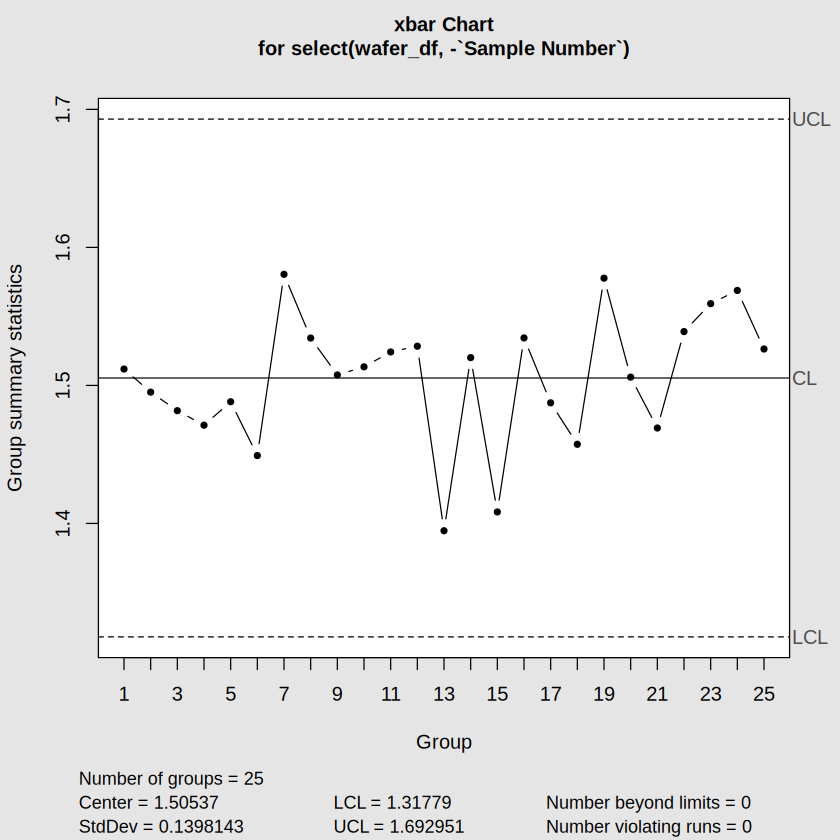

In [5]:
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Wafer Data ##

wafer_df <- read_excel("Wafer Data.xlsx")

## Data Integrity Check ##

wafer_df |>
  glimpse()

## These data are organized in "wide format"
## where each row represents a point in time
## rather than a unique observation.
## For the qcc package, wide data is typically
## what we need. ##

## Save and plot phase 1 xbar chart ##

phase1_xbar <- qcc(wafer_df |> select(-`Sample Number`),
                   type = "xbar",
                   plot = TRUE)

### Interpreting the Phase I $\bar{X}$-Chart

From this chart we can read off the key Phase I estimates directly:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{\bar{x}}$) | $1.505$ |
| Std. Dev. ($\hat{\sigma}$) | $0.1398$ |
| LCL | $1.32$ |
| UCL | $1.69$ |

Note that the default estimation technique for the process standard deviation given by the `qcc` function is the one stated above. We have alternative methods for estimating process standard deviation that we'll discuss later in this class.

The chart also reports the number of points exceeding the control limits (zero in this case) and the number of **violating runs**, which are sequences of plotted points that are statistically improbable even when all points fall within the control limits.

> **What is a violating run?** Imagine 10 consecutive points all plotting above the centerline but below the UCL. Each individual point looks fine, but the pattern as a whole is highly unlikely under a stable, in-control process. Runs like this can signal a systematic shift in the process that the control limits alone wouldn't catch.

Let's now examine the Phase 1 R Chart:

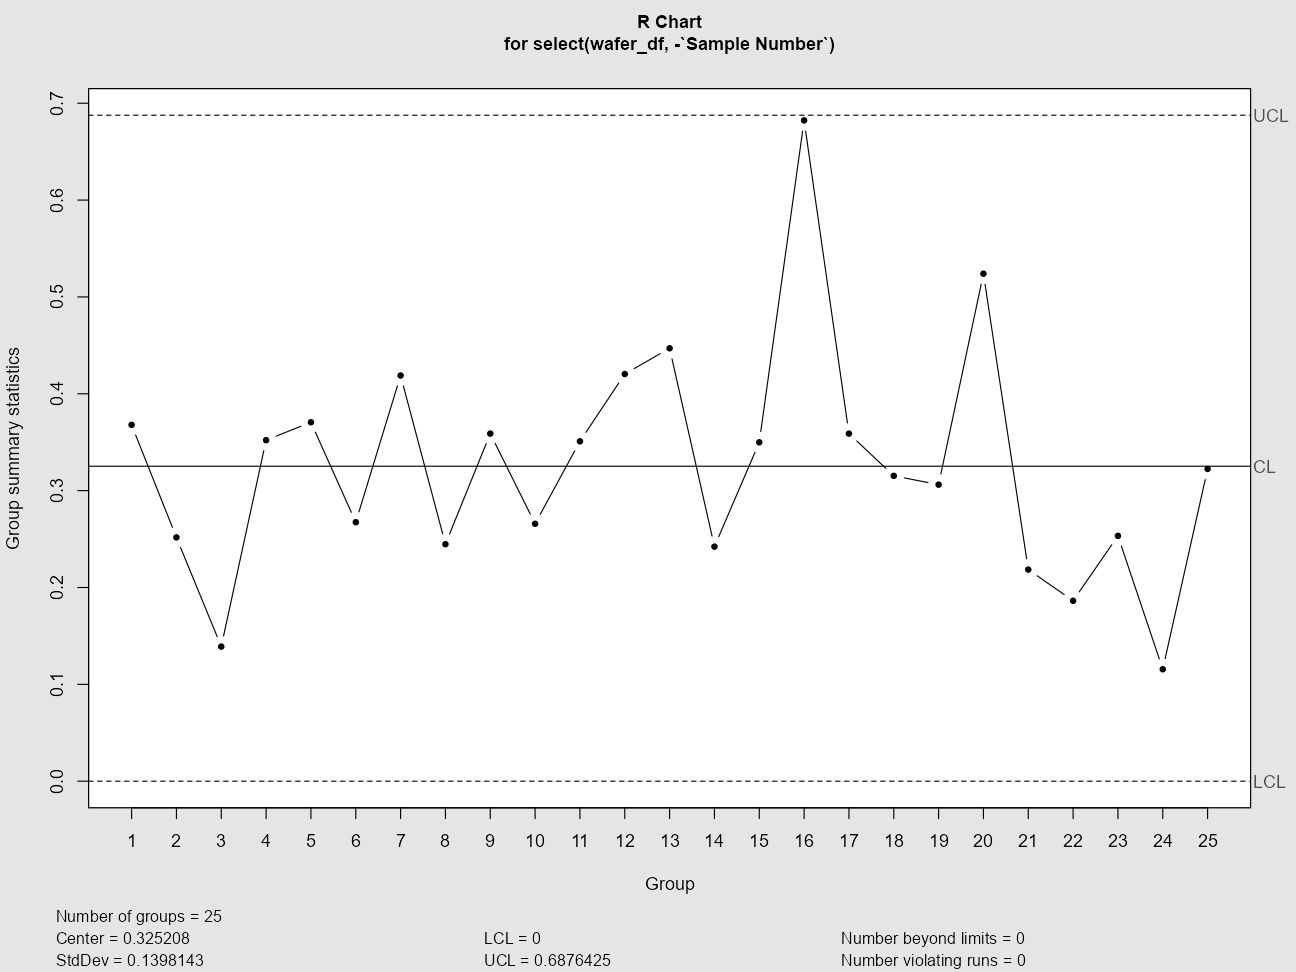

In [ ]:
## Save and plot Phase 1 R Chart ##

phase1_r <- qcc(wafer_df |> select(-`Sample Number`),
                 type = "R",
                 plot = TRUE)

### Interpreting the Phase 1 R-Chart

Similarly, we can read off Phase 1 estimates directly from this figure:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{R}$) | $0.3252$ |
| Std. Dev. ($\hat{\sigma}$) | $0.1398$ |
| LCL | $0$ |
| UCL | $0.6876$ |

As was the case with the $\bar{x}$-chart, we had no points beyond the limits and no violating runs.  

In sum, this would indicate to us that we have historically had an in-control, stable process where:

\begin{align*}
\hat{\mu}_0 &= \bar{\bar{x}} = 1.505 \\
\hat{\sigma}_0 &= \frac{\bar{R}}{d_2} = \frac{0.3252}{2.326} \\
&\approx 0.1398
\end{align*}

## Process Capability

Once Phase I establishes that a process is **in statistical control**, we move to a second question as part of Phase I:

> *Is the process actually producing items that meet specifications?*

A process can be perfectly in control — behaving consistently and predictably — and still be producing nonconforming units if its natural variability is too large. This is the concept of **process capability**.

---

### Specification Limits vs. Control Limits

It's important not to confuse these two:

| | Set By | Purpose |
|---|---|---|
| **Control Limits** | The data / process | Detect when the process has changed |
| **Specification Limits (USL/LSL)** | The customer or engineer | Define what's an acceptable product |

A process is **capable** when its natural spread (typically $\hat{\mu} \pm 3\hat{\sigma}$, the **natural tolerance limits**) falls *inside* the specification limits.

---

### Visual Intuition

The plot below illustrates what we're examining in process capability:

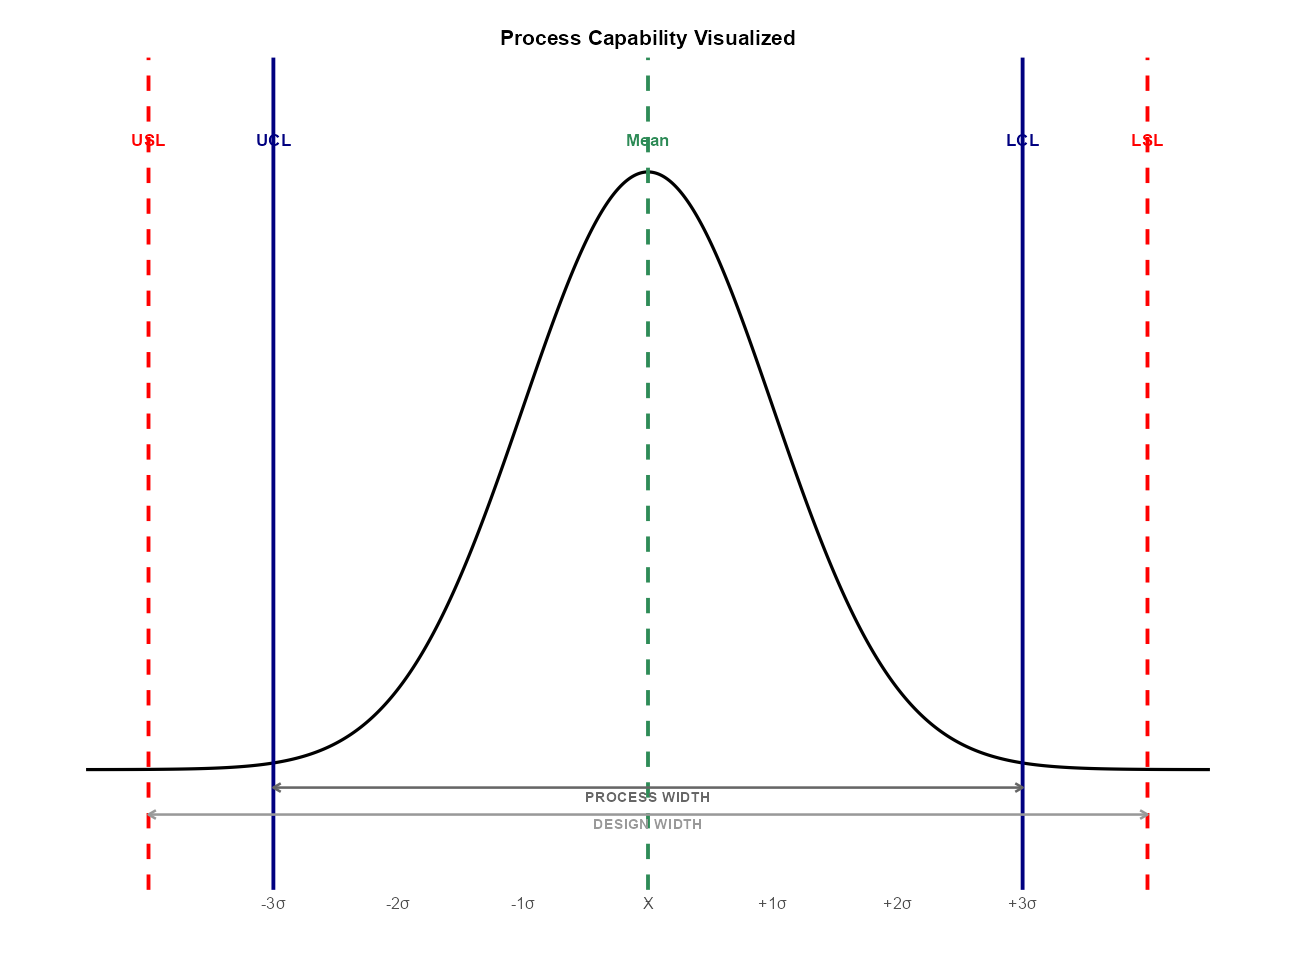

In [ ]:
library(tidyverse)

# Parameters
mu <- 0
sigma <- 1
x <- seq(-4.5, 4.5, length.out = 1000)
y <- dnorm(x, mu, sigma)
df <- data.frame(x = x, y = y)

ggplot(df, aes(x, y)) +
  # Normal curve
  geom_line(linewidth = 1) +

  # UCL and LCL (Voice of the Process, ±3σ)
  geom_vline(xintercept = c(-3, 3), color = "navy", linewidth = 1.2) +

  # USL and LSL (Voice of the Customer, outside ±3σ)
  geom_vline(xintercept = c(-4, 4), color = "red", linewidth = 1.2,
             linetype = "dashed") +

  # Mean
  geom_vline(xintercept = 0, color = "#2e8b57", linewidth = 1.2,
             linetype = "dashed") +

  labs(title = "Process Capability Visualized") +

  # Sigma tick labels on x-axis
  scale_x_continuous(
    breaks = c(-3, -2, -1, 0, 1, 2, 3),
    labels = c("-3σ", "-2σ", "-1σ", "X̄", "+1σ", "+2σ", "+3σ")
  ) +

  # Process width arrow
  annotate("segment", x = -3, xend = 3, y = -0.012, yend = -0.012,
           arrow = arrow(ends = "both", length = unit(0.2, "cm")),
           color = "gray40", linewidth = 0.8) +
  annotate("text", x = 0, y = -0.018, label = "PROCESS WIDTH",
           size = 3.5, color = "gray40", fontface = "bold") +

  # Design width arrow
  annotate("segment", x = -4, xend = 4, y = -0.030, yend = -0.030,
           arrow = arrow(ends = "both", length = unit(0.2, "cm")),
           color = "gray60", linewidth = 0.8) +
  annotate("text", x = 0, y = -0.036, label = "DESIGN WIDTH",
           size = 3.5, color = "gray60", fontface = "bold") +

  # Line labels: UCL, LCL
  annotate("text", x = -3, y = 0.42, label = "UCL", color = "navy",
           fontface = "bold", size = 4) +
  annotate("text", x = 3, y = 0.42, label = "LCL", color = "navy",
           fontface = "bold", size = 4) +

  # Line labels: USL, LSL
  annotate("text", x = -4, y = 0.42, label = "USL", color = "red",
           fontface = "bold", size = 4) +
  annotate("text", x = 4, y = 0.42, label = "LSL", color = "red",
           fontface = "bold", size = 4) +

  # Mean label
  annotate("text", x = 0, y = 0.42, label = "Mean", color = "#2e8b57",
           fontface = "bold", size = 4) +

  # Theme cleanup
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 11),
    plot.margin = margin(t = 20, r = 20, b = 40, l = 20)
  ) +
  coord_cartesian(ylim = c(-0.055, 0.45), clip = "off")

In this case, the natural tolerance band is more narrow than the specification band.
> This implies that the process is **capable**

If we were to observe a process that is not capable, the natural tolerance band would be wider than the specification band. In this case, the process would produce a significant number of defects, and we would need to investigate and improve the process to meet customer requirements.

This is well and good, but how do we quantify the degree of capability or lackthereof? We have a few different ways!

### Method 1: Fraction Non-Conforming (FNC)

One way to measure capability is by estimating the **fraction non-conforming (FNC)** — the proportion of output we would expect to fall outside the specification limits, even when the process is in statistical control.

Returning to the wafer example, suppose our specification limits are $1.50 \pm 0.50$, giving $LSL = 1.00$ and $USL = 2.00$. Recall our estimate of the process standard deviation:

$$\hat{\sigma} = \frac{\bar{R}}{d_2} = \frac{0.3252}{2.326} \approx 0.1398$$

The FNC is simply the probability of an observation falling outside the spec limits:

$$\text{FNC} = P(x < 1.00) + P(x > 2.00)$$

$$= P\!\left(Z < \frac{1.00 - 1.5056}{0.1398}\right) + \left(1 - P\!\left(Z < \frac{2.00 - 1.5056}{0.1398}\right)\right)$$

$$= P(Z < -3.617) + (1 - P(Z < 3.537)) \approx 0.00035$$

An FNC of $0.035\%$ means that for every 100,000 wafers produced, we would expect roughly **35 nonconforming units** — even with a perfectly stable, in-control process.

Here is how we'd manually calculate this value using R:



In [ ]:
## Calculating Fraction Non-Conforming ##

pnorm(1,mean=phase1_xbar$center,
      sd=phase1_xbar$std.dev) +
pnorm(2,mean=phase1_xbar$center,sd=phase1_xbar$std.dev,
      lower.tail=FALSE)

[1] 0.0003521822

### Method 2: The Process Capability Ratio $C_p$

A more widely used measure is the **Process Capability Ratio**, $C_p$:

$$C_p = \frac{USL - LSL}{6\sigma}$$

Since $\sigma$ is rarely known, we substitute our estimate $\hat{\sigma}$:

$$\hat{C}_p = \frac{USL - LSL}{6\hat{\sigma}} = \frac{2.00 - 1.00}{6(0.1398)} \approx 1.192$$

**How to interpret $\hat{C}_p$:**

| Value | Interpretation |
|---|---|
| $\hat{C}_p > 1$ | Natural tolerance limits fall *inside* the spec limits — the process is capable |
| $\hat{C}_p = 1$ | Natural tolerance limits exactly match the spec limits — barely capable |
| $\hat{C}_p < 1$ | Natural tolerance limits exceed the spec limits — nonconformance is inevitable |

In our example, $\hat{C}_p \approx 1.192$ means the specification range is about 1.19 times the width of the natural tolerance range. Thus, the process has a modest capability cushion.

The reciprocal of $\hat{C}_p$ expresses this as a percentage of the specification band being consumed by the process:

$$\hat{p} = \frac{1}{\hat{C}_p} \times 100\% = \frac{1}{1.192} \times 100\% \approx 83.9\%$$

The process is using up about 84% of the available specification band. So we have some room, but not a lot. Values above 100% signal that the process will produce a large quantity nonconforming units.

We can use the `qcc` package to have this, FNC, and other metrics returned to us in a single call:

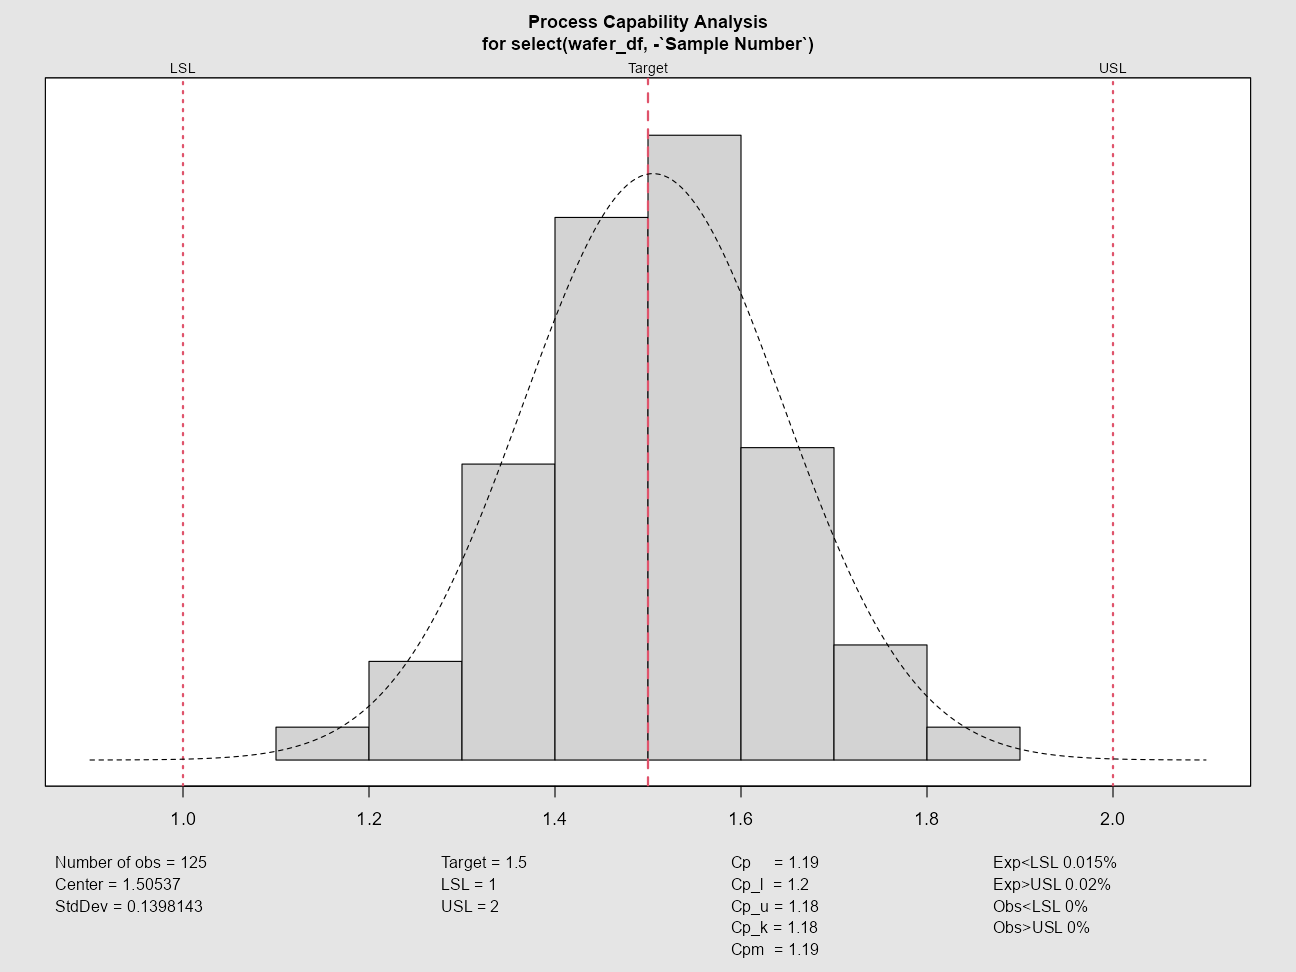


Process Capability Analysis

Call:
process.capability(object = phase1_xbar, spec.limits = c(1, 2),     target = 1.5, std.dev = phase1_xbar$std.dev, nsigmas = 3)

Number of obs = 125          Target = 1.5
       Center = 1.505           LSL = 1
       StdDev = 0.1398          USL = 2

Capability indices:

      Value   2.5%  97.5%
Cp    1.192  1.044  1.340
Cp_l  1.205  1.070  1.340
Cp_u  1.179  1.047  1.312
Cp_k  1.179  1.021  1.337
Cpm   1.191  1.043  1.339

Exp<LSL 0.015%	 Obs<LSL 0%
Exp>USL 0.02%	 Obs>USL 0%


In [ ]:
## Estimating Process Capability ##

process.capability(phase1_xbar,
                   spec.limits=c(1,2),
                   target=1.50,
                   std.dev=phase1_xbar$std.dev,
                   nsigmas=3)

- To note:

$$\text{Exp < LSL} + \text{Exp > USL} = \text{FNC} $$

### A Note on Normality

The $\bar{X}$ and R charts, and the capability calculations above, assume the underlying process follows a **Normal distribution**. In practice:

- The **$\bar{X}$ chart** is fairly robust to mild or moderate departures from normality
- The **R chart** is considerably more sensitive to non-normality
- In the presence of **heavy skew** (e.g., time-to-event or lifetime data), neither chart performs reliably

When normality is unknown or unreasonable to assume, a **nonparametric control chart** is the better choice. [Chakraborti and Graham (2019)](https://www.tandfonline.com/doi/pdf/10.1080/08982112.2018.1549330?casa_token=g1Uqu2CV5o4AAAAA:D_jDEoUV3tpra_9Y6xxKLqxlOFKyS6LhNu6t7fzuxkF0tHedIn2pAUSSlofWxmfrNxsJXpHY7gKN7A) provides a thorough overview of multiple options.

---

## Chart Efficiency: ARL and OC Curves

We've established how to assess whether a process is capable, but how do we evaluate whether a control chart is doing its job well? Recall the two desirable properties of any control chart:

1. If the process is **out of control (OOC)**, the chart signals in as few samples as possible
2. If the process is **in control (IC)**, false alarms are infrequent

Two tools let us quantify these properties: **Operating Characteristic (OC) Curves** and **Average Run Length (ARL)**.

---

### Operating Characteristic Curves

An OC curve plots the probability of a **Type II error** ($\beta$) (i.e., failing to detect a real shift) as a function of the size of that shift.

For the $\bar{X}$-chart, given a shift of $k\sigma$ away from target, the probability of failing to detect on the first post-shift sample is:

$$\beta = P(LCL \leq \bar{x} \leq UCL \mid \mu_1 = \mu_0 + k\sigma)$$

With a little algebra this simplifies to:

$$\beta = \Phi(L - k\sqrt{n}) - \Phi(-L - k\sqrt{n})$$

The OC curve (Figure 6.13 in the Montgomery text) plots $\beta$ against $k$ for various sample sizes $n$, making the tradeoff between sensitivity and sample size immediately visible.

![OC Curve for Xbar Chart](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-2-Shewhart-Charts-for-Variables/OCCxbar.JPG)

Again, we have a nice `qcc` function to help us generate these curves:

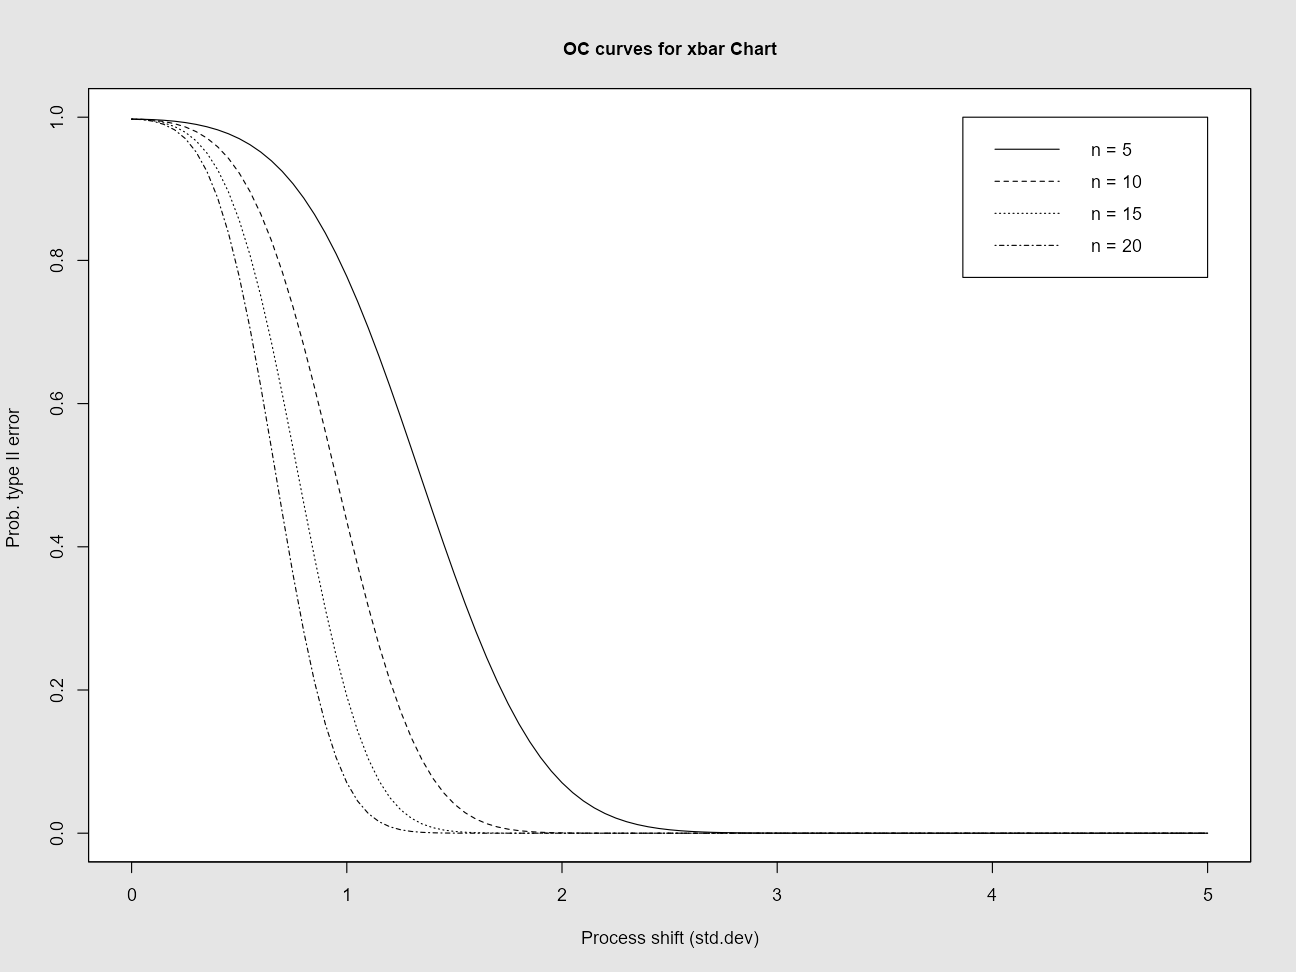

In [ ]:
## Generate OC Curves for Phase 1 X-Bar Chart
## comparing n = 5, 10, 15, and 20 ##

qcc::oc.curves.xbar(phase1_xbar,n=c(5,10,15,20))

Intuitively, a larger sample has better ability to detect a process shift, especially for $k\leq1.5$.

### Average Run Length (ARL)

The OC curve gives us $\beta$ at a single time point. **ARL** asks a more practical question: *on average, how many samples will it take before the chart signals?*

Since each sample is assumed to be an independent Bernoulli trial with detection probability $(1 - \beta)$, the run length $RL$ follows a **geometric distribution**:

$$P(RL = r) = \beta^{r-1}(1 - \beta), \qquad r = 1, 2, 3, \ldots$$

Its expectation gives us the out-of-control ARL:

$$ARL_1 = E[RL] = \frac{1}{1 - \beta}$$

A smaller $ARL_1$ is better — it means real shifts are caught quickly.

---

### In-Control ARL ($ARL_0$)

On the flip side, we also want to know how long the chart runs before producing a **false alarm** when the process is actually in control. The same geometric argument applies, but now with $\alpha$ as the false-alarm probability:

$$ARL_0 = \frac{1}{\alpha}$$

For the standard $\alpha = 0.0027$ (i.e., $\pm 3\sigma$ control limits):

$$ARL_0 = \frac{1}{0.0027} \approx 371$$

This means that on average, a $3\sigma$ chart will produce a false alarm roughly **once every 371 samples** — a commonly cited benchmark in practice.

**Summarizing the ARL tradeoff:**

| | Want | Driven By |
|---|---|---|
| $ARL_0$ (IC) | **Large** — few false alarms | $\alpha$, control limit width |
| $ARL_1$ (OOC) | **Small** — detect shifts fast | $\beta$, shift size $k$, sample size $n$ |

Widening the control limits increases $ARL_0$ (fewer false alarms) but also increases $ARL_1$ (slower detection). Narrowing them does the opposite. Increasing $n$ improves both simultaneously, but at a cost. This is the fundamental design tradeoff in control charting.